# Exploratory analysis

This notebook looks at the cleaned 2025 operations extract for a fictional eight-plant fleet. The plants, regions, and values are synthetic. They do not represent any utility's performance.

The question is the same one the Power BI page is built to answer: **how effectively are the assets performing, and where should operations look?**

`scripts/analyze_data.py` prints the KPI tables. This notebook draws the patterns those tables describe. It reads `data/processed/plant_operations_daily_clean.csv`, so run the generator and the cleaner before executing these cells.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

CLEAN_PATH = ROOT / "data" / "processed" / "plant_operations_daily_clean.csv"
operations = pd.read_csv(CLEAN_PATH, parse_dates=["Date"])
operations["Generation_Imputed"] = (
    operations["Generation_Imputed"].map(lambda value: str(value).strip().lower() == "true")
)

TECH_COLORS = {
    "Natural Gas": "#c47b2b",
    "Wind": "#2a9d8f",
    "Solar": "#e9c46a",
    "Battery Energy Storage": "#5c4d7a",
}
MONTH_ORDER = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December",
]

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlelocation": "left",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.linestyle": ":",
    "grid.alpha": 0.6,
})

print(f"{len(operations):,} rows, {operations['Plant_ID'].nunique()} plants")
print(f"{operations['Date'].min().date()} through {operations['Date'].max().date()}")
print(f"Imputed generation days: {int(operations['Generation_Imputed'].sum())}")

2,920 rows, 8 plants
2025-01-01 through 2025-12-31
Imputed generation days: 4


## Monthly generation

A single annual total hides the shape of the year. Solar should rise toward summer. Wind should be stronger in the windier months. Natural gas should drop in April, when Riverbend Combined Cycle is on its planned outage. Battery discharge should pick up in the summer and winter peaks.

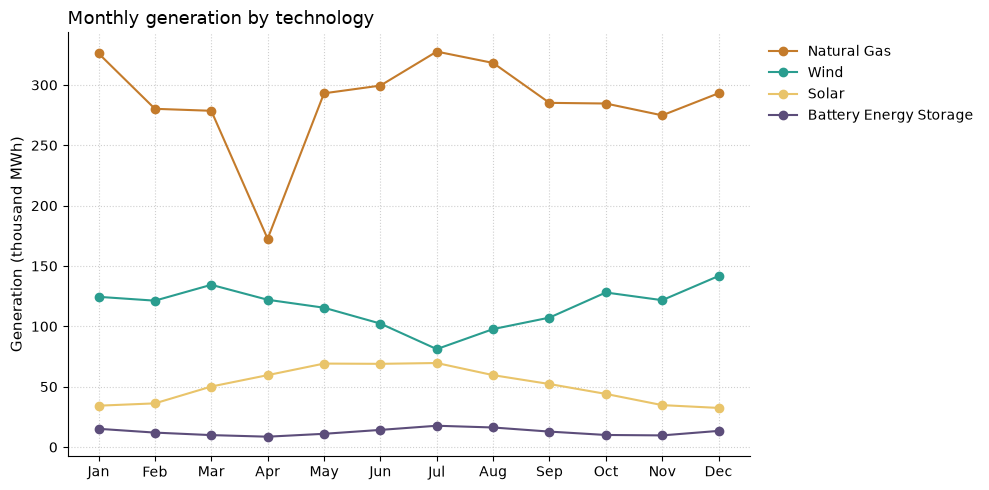

In [2]:
monthly = (
    operations.groupby(["Month", "Month_Name", "Generation_Type"], as_index=False)
    ["Actual_Generation_MWh"]
    .sum()
)

fig, ax = plt.subplots(figsize=(10, 5))
for technology, color in TECH_COLORS.items():
    series = monthly.loc[monthly["Generation_Type"] == technology].sort_values("Month")
    ax.plot(
        series["Month"],
        series["Actual_Generation_MWh"] / 1000,
        marker="o",
        color=color,
        label=technology,
    )

ax.set_xticks(range(1, 13))
ax.set_xticklabels([name[:3] for name in MONTH_ORDER])
ax.set_ylabel("Generation (thousand MWh)")
ax.set_title("Monthly generation by technology")
ax.legend(frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")
fig.tight_layout()
plt.show()

April is the trough, and it is the gas line that falls. Solar peaks in early summer. Wind is softest in July and strongest in December. The technologies offset each other for most of the year. The month that breaks that balance is the planned gas outage, not the weather.

## Capacity factor

Capacity factor is actual energy divided by the energy the plant would have produced running at full power for every hour in the year:

`actual MWh / (capacity MW x 24 x days)`

Read it against the job of the asset. A peaker and a battery are supposed to sit well below a combined-cycle unit.

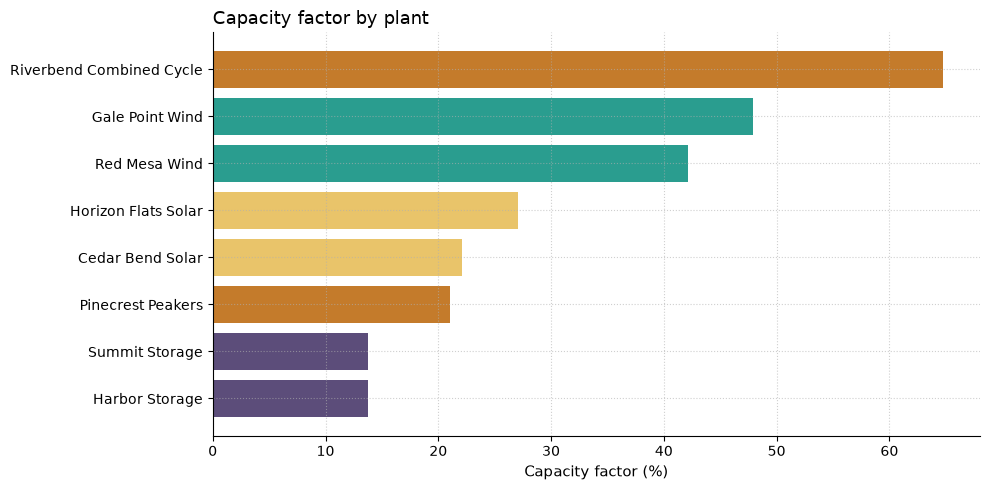

In [3]:
plants = (
    operations.groupby(
        ["Plant_Name", "Generation_Type", "Capacity_MW"], as_index=False
    )
    .agg(
        actual_mwh=("Actual_Generation_MWh", "sum"),
        expected_mwh=("Expected_Generation_MWh", "sum"),
        days=("Date", "nunique"),
        planned_hours=("Planned_Downtime_Hours", "sum"),
        unplanned_hours=("Unplanned_Downtime_Hours", "sum"),
        maintenance_cost=("Maintenance_Cost", "sum"),
    )
)
plants["capacity_factor"] = plants["actual_mwh"] / (plants["Capacity_MW"] * 24 * plants["days"])
plants["variance_pct"] = (plants["actual_mwh"] - plants["expected_mwh"]) / plants["expected_mwh"]
plants = plants.sort_values("capacity_factor")

fig, ax = plt.subplots(figsize=(10, 5))
colors = plants["Generation_Type"].map(TECH_COLORS)
ax.barh(plants["Plant_Name"], plants["capacity_factor"] * 100, color=colors)
ax.set_xlabel("Capacity factor (%)")
ax.set_title("Capacity factor by plant")
fig.tight_layout()
plt.show()

Riverbend, the combined-cycle plant, is near 65%. Pinecrest, the peaker, is near 21% because it runs for peaks and then waits. The two batteries are near 14% because a four-hour storage asset discharges for part of the day, while the formula still divides by 24 hours. Horizon Flats sits above Cedar Bend. Both are solar, and the desert site has the stronger resource.

The bar colors match the monthly chart: gas, wind, solar, storage.

## Actual versus expected

Variance percent is `(actual - expected) / expected`. A negative bar finished the year below its own plan. This view is easier to compare than raw megawatt-hours, because Riverbend's energy total would otherwise dwarf every other plant.

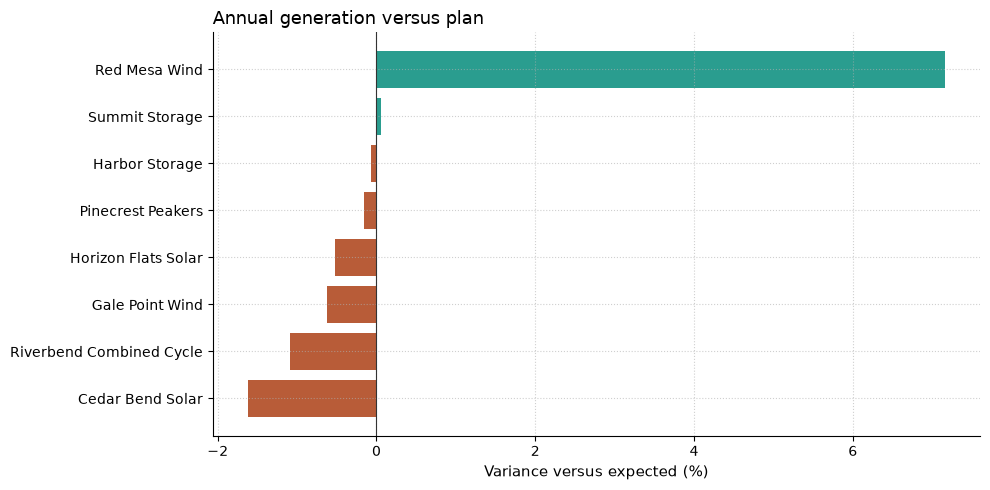

In [4]:
variance = plants.sort_values("variance_pct")
bar_colors = ["#b85c38" if value < 0 else "#2a9d8f" for value in variance["variance_pct"]]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(variance["Plant_Name"], variance["variance_pct"] * 100, color=bar_colors)
ax.axvline(0, color="#333333", linewidth=0.8)
ax.set_xlabel("Variance versus expected (%)")
ax.set_title("Annual generation versus plan")
fig.tight_layout()
plt.show()

Most plants finish within about 2% of plan. Red Mesa is the exception, about 7% above its expected generation. That annual beat can hide a noisy forecast: on a typical day Red Mesa's actual output still wanders well away from the daily expectation. The gas plants stay close to plan because their output is dispatched. Riverbend's shortfall lines up with its unplanned hours. The April outage was already inside the expected generation, so it does not show up as a miss.

## Downtime and maintenance cost

Planned hours are outages the fleet scheduled. Unplanned hours are forced outages. Sorting by unplanned hours puts the follow-up list at the top. Cost is a separate question: a long planned outage on a large unit is where the money goes.

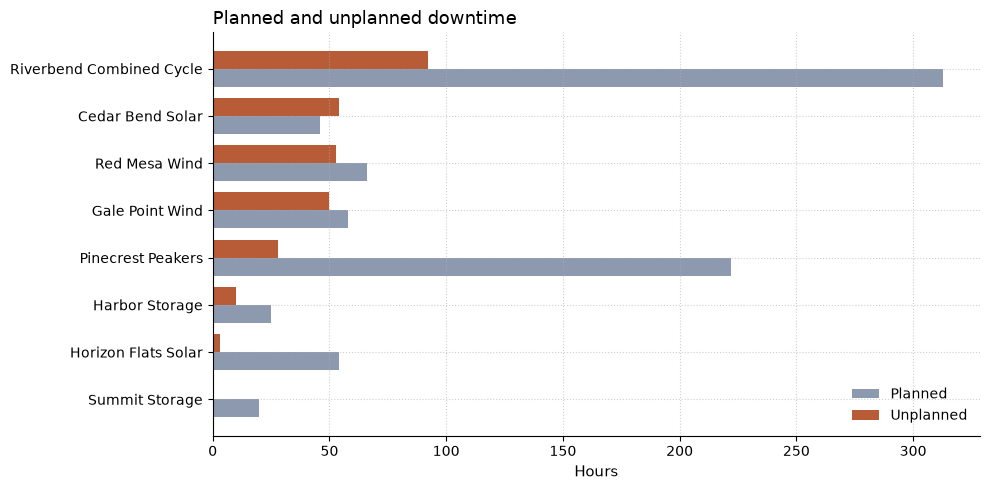

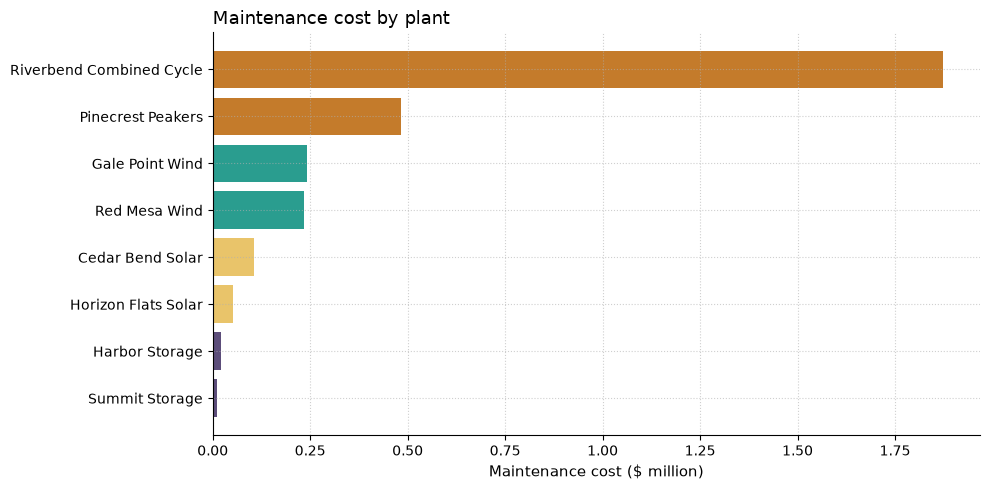

In [5]:
downtime = plants.sort_values("unplanned_hours")
positions = range(len(downtime))
bar_height = 0.38

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(
    [position - bar_height / 2 for position in positions],
    downtime["planned_hours"],
    height=bar_height,
    color="#8d99ae",
    label="Planned",
)
ax.barh(
    [position + bar_height / 2 for position in positions],
    downtime["unplanned_hours"],
    height=bar_height,
    color="#b85c38",
    label="Unplanned",
)
ax.set_yticks(list(positions))
ax.set_yticklabels(downtime["Plant_Name"])
ax.set_xlabel("Hours")
ax.set_title("Planned and unplanned downtime")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

cost = plants.sort_values("maintenance_cost")
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(
    cost["Plant_Name"],
    cost["maintenance_cost"] / 1_000_000,
    color=cost["Generation_Type"].map(TECH_COLORS),
)
ax.set_xlabel("Maintenance cost ($ million)")
ax.set_title("Maintenance cost by plant")
fig.tight_layout()
plt.show()

Riverbend leads both unplanned hours and maintenance cost. Its planned-outage bar is the April maintenance window, and that window is most of the fleet's spend. Pinecrest also has a long planned bar and the second-largest cost, but those hours remove less energy because a peaker was not scheduled to run much of that time.

Cedar Bend is second in unplanned hours. Horizon Flats, the other solar plant, has almost none. That gap is a plant-level question, not a technology question. Hours are not the same as exposure: Cedar Bend's 95 MW times those hours removes much less capacity than Riverbend's 92 hours at 540 MW.

The numbered observations and the exact KPI totals are printed by `scripts/analyze_data.py`.